In [1]:
import numpy as np
import pandas as pd

import time
import warnings
import os
import sys

warnings.filterwarnings("ignore")
sys.stderr = open(os.devnull, 'w')

## Contents
1. **Time-series data exploration** <br> _Time-series plot<br>Time-series decomposition_
2. **Models and parameters identification** <br>_SARIMA fine-tuning<br>Kats metalearning_
3. **Machine learning setup** <br> _Datasets<br>Methods and models_
4. **Training and Forecasting** <br> _Direct 60-day forecasting (fh=60)<br>Rolling 1-day forecasting (fh=1)_
5. **Models comparison** <br>_Performance summarization._

Data source: https://www.kaggle.com/datasets/mukeshmanral/univariate-time-series

# 1) Time-series data exploration

In [2]:
ts= pd.read_csv('/home/petewojtczak/datasets_csv/date_count.csv')
ts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 578 entries, 0 to 577
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    578 non-null    object
 1   count   578 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 9.2+ KB


In [3]:
ts

,Date,count
0,2012-08-25,3
1,2012-08-26,3
2,2012-08-27,2
3,2012-08-28,2
4,2012-08-29,2
...,...,...
573,2014-03-21,149
574,2014-03-22,129
575,2014-03-23,119
576,2014-03-24,214


## 1.1) Time-series plot

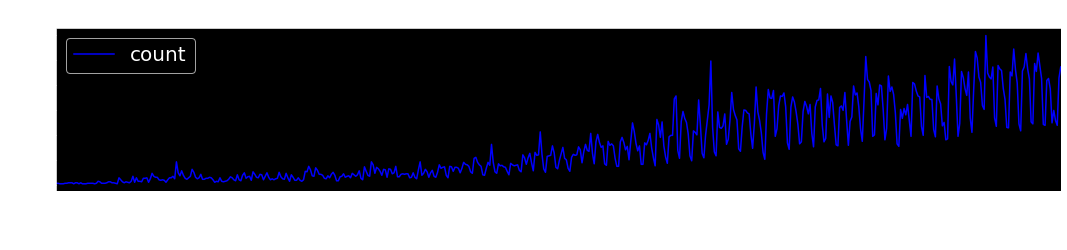

In [4]:
import matplotlib.pyplot as plt
plt.style.use('dark_background')
%matplotlib inline

# some essential preprocessing for plotting
ts['Date'] = pd.to_datetime(ts['Date'])
ts.set_index('Date', inplace=True)

ts.plot(color='blue')
plt.title('count_count time-series', size=20)
plt.xlabel('date', size=20)
plt.ylabel('count', size = 20)
plt.gcf().set_size_inches(18, 3)
plt.legend(loc=2, prop={'size': 20})
plt.show()

## 1.2) Time-series decomposition

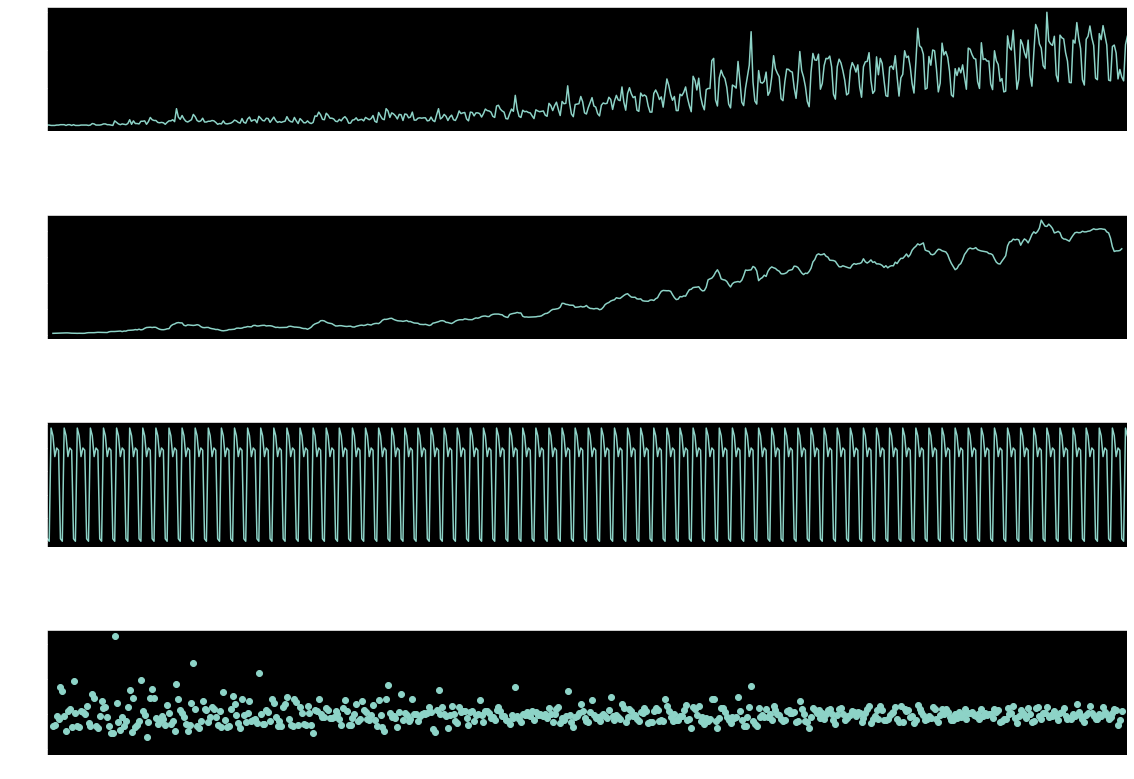

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose

decompose = seasonal_decompose(ts, model='multiplicative')
decompose.plot()
plt.gcf().set_size_inches(18, 12)
plt.show()

Let's have a closer look at the seasonality.

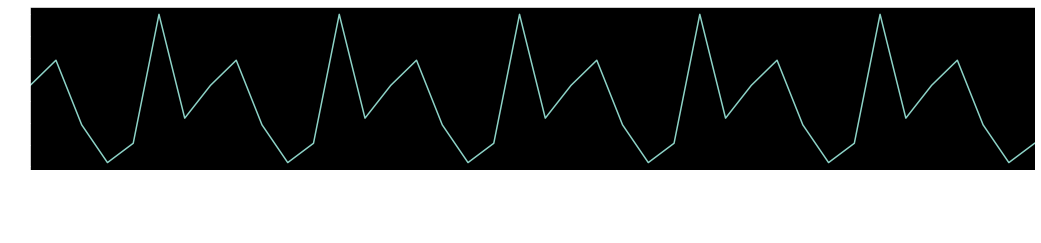

In [6]:
magified_seasonality = ts.iloc[50:90]
magified_seasonality.asfreq('D')
decomp = seasonal_decompose(magified_seasonality, model='multiplicative')
decomp.seasonal.plot()
plt.gcf().set_size_inches(18, 3)
plt.show()

It is now evident that weekly seasonality is present.

# 2) Models and parameters identification
First, let's mention SARIMA. Since it might be worthwhile, some time is dedicated to fine-tuning the parameters of this renowned classic. Additionally, we would like to venture off the beaten path and employ an AutoML solution by Kats, specifically metalearning. This approach features well-ranged, randomized defaults that promise to comprehensively search the parameter spaces of specified models.

## 2.1) SARIMA fine-tuning

In [7]:
import statsmodels.api as sm
import statsmodels.tsa.api as smt

# adopted from https://www.kaggle.com/kashnitsky/topic-9-part-1-time-series-analysis-in-python?scriptVersionId=50985180&cellId=80
def tsplot(y, lags=None, figsize=(12, 7), style='bmh'):
    """
        Plot time series, its ACF and PACF, calculate Dickey–Fuller test
        
        y - timeseries
        lags - how many lags to include in ACF, PACF calculation
    """
    if not isinstance(y, pd.Series):
        y = pd.Series(y)        
        
    with plt.style.context(style):    
        fig = plt.figure(figsize=figsize)
        layout = (2, 2)
        ts_ax = plt.subplot2grid(layout, (0, 0), colspan=2)
        acf_ax = plt.subplot2grid(layout, (1, 0))
        pacf_ax = plt.subplot2grid(layout, (1, 1))
        
        # it is a very nice function but we will make it dark
        fig.patch.set_facecolor('black')
        ts_ax.set_facecolor('black')
        acf_ax.set_facecolor('black')
        pacf_ax.set_facecolor('black')
        
        y.plot(ax=ts_ax)
        p_value = sm.tsa.stattools.adfuller(y)[1]
        ts_ax.set_title('Time Series Analysis Plots\n Augmented Dickey-Fuller: p={0:.5f}'.format(p_value))
        smt.graphics.plot_acf(y, lags=lags, ax=acf_ax)
        smt.graphics.plot_pacf(y, lags=lags, ax=pacf_ax)
        plt.tight_layout()

In [8]:
# split is necessary at this stage due to occurrence of statistical interference 
y_train = ts.iloc[:len(ts)-60]
y_test = ts.iloc[len(ts)-60:]

### Stationarity

According to the plot, trend and heteroscedasticity seems to be obvious. Cubic root transformation is applied.

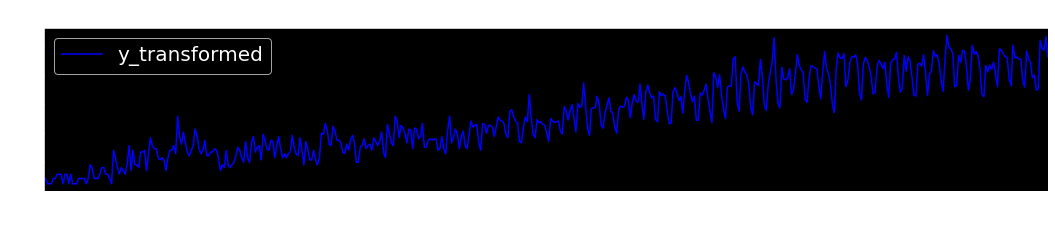

In [9]:
y_train['y_transformed'] = np.cbrt(y_train['count'])

y_train['y_transformed'].plot(color='blue')
plt.title('transformed time series', size=20)
plt.xlabel('time', size=20)
plt.ylabel('counts', size = 20)
plt.gcf().set_size_inches(18, 3)
plt.legend(loc=2, prop={'size': 20})
plt.show()

Heteroscedasticity appears to be pretty much gone. Trend also looks better, more linear. Let's remove it, and then have a closer look at the data.

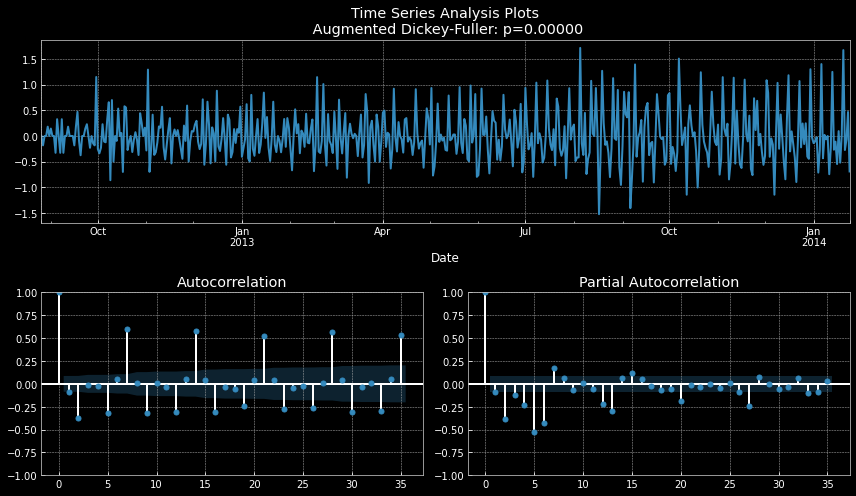

In [10]:
y_train['y_transformed_diff'] = y_train['y_transformed'] - y_train['y_transformed'].shift(1)
y_train.dropna(inplace=True)
tsplot(y_train['y_transformed_diff'], lags=35)

ADF indicates no unit root. ACF confirms weekly seasonality. This needs some attention. Hopefully, dealing with sesonality will address the slightly reappeared heteroscedasticity as well.

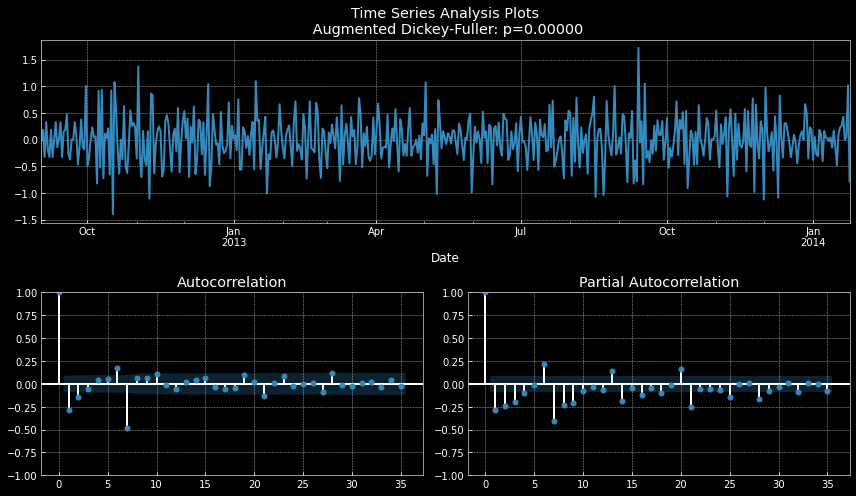

In [11]:
y_train['y_transformed_diff_sdiff'] = y_train['y_transformed_diff'] - y_train['y_transformed_diff'].shift(7)
y_train.dropna(inplace=True)
tsplot(y_train['y_transformed_diff_sdiff'], lags=35)

This is exacly what we wanted to see. Now, SARIMA parameters can finally be derived.

* p is most probably 3 since it is the last significant lag on the PACF, after which most others are not significant.
* d equals 1 because we had first differences.
* q should most likely be 2 as seen on the ACF.
* P might be 4, since the 7th lag is significant and the 14th, 21st, and 28th lags are somewhat significant on the PACF.
* D again equals 1 because we performed seasonal differentiation.
* Q is deemed to be 1. The 7th lag on ACF is significant while the 14th is not.
* s is, in our case, 7.


In [12]:
# transformed data will be useful in case of SARIMA 
y_train_sarima = y_train

## 2.2) Kats metalearning
This tool is designed to select the best-performing model and its parameters from a predefined list for a given time-series. Subsequently, this model, along with SARIMA and the other models in consideration, is then used in the proper training computation (generating forecasts, calculating erros etc.).

In [13]:
from kats.consts import TimeSeriesData
from kats.consts import SearchMethodEnum
from kats.models.holtwinters import HoltWintersModel, HoltWintersParams
from kats.models.stlf import STLFModel, STLFParams
from kats.models.theta import ThetaModel, ThetaParams
from kats.models.metalearner.get_metadata import GetMetaData

# Kats expects specified format
y_train = ts.iloc[:len(ts)-60]
y_train.reset_index(inplace=True)
y_train.columns = ["time", "value"]
y_train = TimeSeriesData(y_train)

print('Getting metadata ...')
start = time.time()

MD = GetMetaData(
    all_models={"holtwinters": HoltWintersModel,"theta": ThetaModel,"stlf": STLFModel,},
    all_params={"holtwinters": HoltWintersParams,"theta": ThetaParams,"stlf": STLFParams,},
    data=y_train,
    error_method='mae')

y_train_metadata = MD.get_meta_data()

end = time.time()
print('Metadata successfully generated. ({:.2f} s)'.format(end-start))

Getting metadata ...
Metadata successfully generated. (21.22 s)


Metalearner suggested model and its specification:

In [14]:
print(y_train_metadata['best_model'])
print(y_train_metadata['hpt_res'][y_train_metadata['best_model']])

holtwinters
({'damped': True, 'seasonal_periods': 7, 'trend': 'additive', 'seasonal': 'multiplicative'}, 0.08858539828267603)


# 3) ML setup
In this section, we organize datasets and outline the models and methodologies to be employed. We explore two distinct approaches. The first set of models, affiliated with Kats, aims to directly leverage the inherent temporal order within time-series data. The second set, associated with sklearn and sktime, consists of models originally designed for regression tasks. However, sktime introduces a valuable function, **make_reduction()**, which transforms time-series data into a tabular format, effectively reframing the forecasting task into a regression problem.

## 3.1) Datasets

In [15]:
# container for training data
datasets = {}

# sarima dataset will comprise of transformed values (np.cbrt)
y_train_sarima = y_train_sarima['y_transformed']
y_train_sarima = y_train_sarima.reset_index()
y_train_sarima.columns = ["time", "value"]
y_train_sarima = TimeSeriesData(y_train_sarima)
datasets['SARIMA'] = y_train_sarima

# Metalearner, prophet and holtwinters share the same dataset and data format
datasets['Prophet'] = y_train
datasets['holtwinters'] = y_train


# sklearn works with numpy / pandas datatypes
y_train = ts.iloc[:len(ts)-60]
y_test = ts.iloc[len(ts)-60:]
datasets['ML_sklearn'] = y_train

## 3.2) Methods and models

In [16]:
from kats.models.sarima import SARIMAModel, SARIMAParams
from kats.models.prophet import ProphetModel, ProphetParams

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import ElasticNet
from sklearn.neighbors import KNeighborsRegressor

params = {
    'SARIMA': SARIMAParams(p=3, d=1, q=2,  seasonal_order=(4,1,1,7)),
    'Prophet': ProphetParams(seasonality_mode='multiplicative'),
    'holtwinters': HoltWintersParams(trend="add", damped=True, seasonal="mul", seasonal_periods=7)}

hypergrid = {
    'gbr': {
        "estimator__learning_rate":[0.001, 0.01, 0.1, 0.3, 0.5],
        "estimator__warm_start":[True, False]         
    },
    'enet': {
        "estimator__alpha":[0.001, 0.01, 0.1, 0.2],
        "estimator__warm_start":[True, False],
        "estimator__l1_ratio":[0.01, 0.1, 0.2, 0.3, 0.5]
    },
    'knn': {
        "estimator__weights":['uniform', 'distance'],
        "estimator__n_neighbors":[100 , 150]}}

kats_techniques = {
    'SARIMA': SARIMAModel(data=datasets['SARIMA'], params=params['SARIMA']),
    'Prophet': ProphetModel(datasets['Prophet'], params['Prophet']),
    'holtwinters': HoltWintersModel(data=datasets['holtwinters'], params=params['holtwinters'])}

regressors = {
    'gbr': GradientBoostingRegressor(),
    'enet': ElasticNet(),
    'knn': KNeighborsRegressor()}

# 4) Training and Forecasting
This section encompasses the procedures and essential computations, involving the digestion of datasets and the generation of dataframes containing forecasts.

## 4.1) Direct 60-day forecasting (fh=60)

In [17]:
from sktime.forecasting.base import ForecastingHorizon
from sktime.performance_metrics.forecasting import MeanAbsoluteError

# tabularization
from sktime.forecasting.compose import make_reduction
# hypertuning
from sktime.forecasting.model_selection import (ForecastingGridSearchCV,ExpandingWindowSplitter)

dataframes_fh60 = {}

for technique in datasets.keys():
    if technique in kats_techniques.keys():
        print('*[kats] Starting training for {}...'.format(technique) )
        start = time.time()        
        model = kats_techniques[technique]
        model.fit()        
        fcst = model.predict(steps=60, freq="D")
        fcst.set_index('time', inplace=True)
        if technique=='SARIMA':
            # inverting forecast to original scale for SARIMA
            fcst = fcst.applymap(lambda x: np.power(x,3))      
        dataframes_fh60[technique] = fcst.assign(y_test=y_test['count'])
        end = time.time()
        print(' [kats] {} model fitted. forecasts successfully generated. ({:.2f} s)'.format(technique, end-start))
    else:
        y_train = datasets['ML_sklearn']
        y_train = y_train.asfreq('D')
        fit_models = {}
        for algo in regressors.keys():
            print('*[sklearn] Starting training for {}...'.format(algo))
            start = time.time()
            regressor = regressors[algo]
            # tabularization
            forecaster = make_reduction(regressor, strategy="direct", window_length=7)
            # cross-validation scheme
            fh_cv=ForecastingHorizon(np.arange(1, 31))
            cv = ExpandingWindowSplitter(fh=fh_cv, initial_window=int(len(y_train) - 150), step_length=30)
            # hypergrid tuning
            fgscv = ForecastingGridSearchCV(
                forecaster, 
                cv=cv, 
                param_grid=hypergrid[algo], 
                scoring=MeanAbsoluteError())
            fh=ForecastingHorizon(np.arange(1, 61))
            fgscv.fit(y_train, fh=fh)
            fit_models[algo] = fgscv
            y_pred = fgscv.predict(fh)
            dataframes_fh60[algo] = y_test.assign(y_pred=y_pred)          
            end = time.time()
            print(' [sklearn] {} model fitted. forecasts successfully generated. ({:.2f} s)'.format(algo, end-start))

*[kats] Starting training for SARIMA...
 [kats] SARIMA model fitted. forecasts successfully generated. (5.34 s)
*[kats] Starting training for Prophet...
 [kats] Prophet model fitted. forecasts successfully generated. (1.27 s)
*[kats] Starting training for holtwinters...
 [kats] holtwinters model fitted. forecasts successfully generated. (0.13 s)
*[sklearn] Starting training for gbr...
 [sklearn] gbr model fitted. forecasts successfully generated. (87.31 s)
*[sklearn] Starting training for enet...
 [sklearn] enet model fitted. forecasts successfully generated. (6.40 s)
*[sklearn] Starting training for knn...
 [sklearn] knn model fitted. forecasts successfully generated. (0.75 s)


## 4.2) Rolling 1-day forecasting (fh=1)

In this case, training and forecasting is conducted one after another while the training data grows successively by 1 day.

In [18]:
def evaluate_model_fh_1(ModelClass, params, count_ts, model_name):
    evaluation_df = pd.DataFrame()
    split = len(count_ts) - 60

    while split < len(count_ts):
        model = ModelClass(count_ts[:split], params)
        model.fit()
        fcst = model.predict(steps=1, freq="D")
        evaluation_df = evaluation_df.append(fcst, ignore_index=True)
        split += 1
    
    evaluation_df.set_index('time', inplace=True)
    evaluation_df = evaluation_df.assign(y_test=y_test)

    return evaluation_df

In [19]:
dataframes_fh_1 = {}

for algo in kats_techniques.keys():
    dataframes_fh_1[algo] = pd.DataFrame()
for algo in regressors.keys():
    dataframes_fh_1[algo] = pd.DataFrame()

ts.reset_index(inplace=True)
ts.columns = ['time','value']
count_ts = TimeSeriesData(ts)
y_test = y_test.rename_axis('time')

models = [
    ("Prophet", ProphetModel, params['Prophet']),
    ("SARIMA", SARIMAModel, params['SARIMA']),
    ("holtwinters", HoltWintersModel, params['holtwinters'])
    ]

for model_name, ModelClass, model_params in models:
    print(f'*[kats] Starting training for {model_name}...')
    start = time.time()
    dataframes_fh_1[model_name] = evaluate_model_fh_1(ModelClass, model_params, count_ts, model_name)
    end = time.time()
    print(f' [kats] {model_name} model fitted. forecasts successfully generated. ({end-start:.2f} s)')

from sktime.forecasting.model_evaluation import evaluate

for algo in regressors.keys():
    print(f'*[sktime] Starting training for {algo}...')
    start = time.time()
    cv = ExpandingWindowSplitter(initial_window=int(len(ts)-60), step_length=1)
    evaluation_df = evaluate(forecaster=fit_models[algo].best_forecaster_, y=ts['value'], cv=cv, strategy="refit", return_data=True)
    i=0
    while i < len(evaluation_df):
        evaluation_df.y_test[i] = int(evaluation_df.y_test[i].values)
        evaluation_df.y_pred[i] = float(evaluation_df.y_pred[i].values)
        i+=1
    dataframes_fh_1[algo] = evaluation_df[['y_test', 'y_pred']]
    dataframes_fh_1[algo] = dataframes_fh_1[algo].rename(columns={'y_pred': 'fcst'})
    end = time.time()
    print(f' [sktime] {algo} model fitted. forecasts successfully generated. ({end-start:.2f} s)')

*[kats] Starting training for Prophet...
 [kats] Prophet model fitted. forecasts successfully generated. (73.45 s)
*[kats] Starting training for SARIMA...
 [kats] SARIMA model fitted. forecasts successfully generated. (286.48 s)
*[kats] Starting training for holtwinters...
 [kats] holtwinters model fitted. forecasts successfully generated. (7.83 s)
*[sktime] Starting training for gbr...
 [sktime] gbr model fitted. forecasts successfully generated. (4.75 s)
*[sktime] Starting training for enet...
 [sktime] enet model fitted. forecasts successfully generated. (0.55 s)
*[sktime] Starting training for knn...
 [sktime] knn model fitted. forecasts successfully generated. (0.54 s)


# 5) Performance summary

In [20]:
def fcst_errors(y_test, y_pred, model_name):
    MAPE = np.mean(np.abs((y_pred - y_test) / y_test)) * 100
    RMSE = np.mean((y_pred - y_test)**2)**.5  
    MAE = np.mean(np.abs(y_test - y_pred))
    return({'Model':model_name, 'MAPE':round(MAPE,3), 'RMSE':round(RMSE,3), 'MAE':round(MAE,3)})

## 5.1) Direct 60-day forecasting (fh=60)

In [21]:
for algo, df in dataframes_fh60.items():
    if algo in regressors.keys():
        df.rename(columns={'count': 'y_test'}, inplace=True)
        df.rename(columns={'y_pred': 'fcst'}, inplace=True)

In [22]:
performance_summary_fh60 = pd.DataFrame()
for model, df in dataframes_fh60.items():
    errors = fcst_errors(df.y_test, df.fcst, model)
    performance_summary_fh60 = performance_summary_fh60.append(errors, ignore_index=True)
performance_summary_fh60.set_index('Model',inplace=True)

In [23]:
performance_summary_fh60.sort_values(by='MAE')

,MAE,MAPE,RMSE
Model,,,
holtwinters,21.706,11.210,29.071
Prophet,22.817,11.827,31.406
SARIMA,23.040,11.669,31.130
enet,24.855,14.292,34.410
gbr,49.712,25.545,58.838
knn,59.600,28.135,70.095


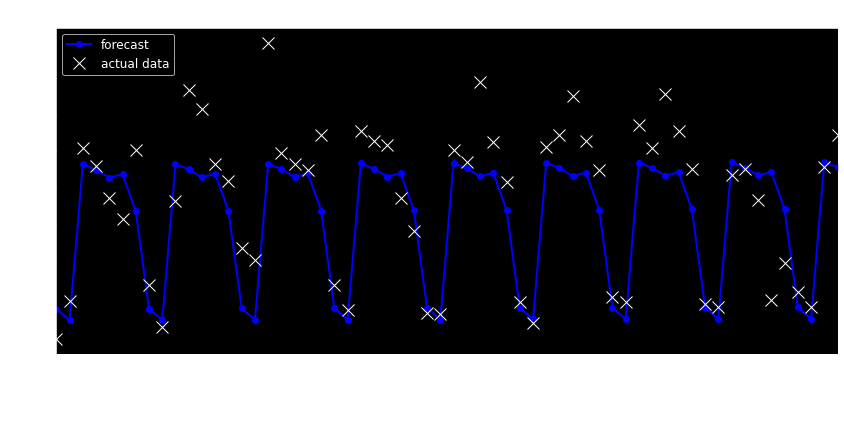

In [24]:
dataframes_fh60['holtwinters'].fcst.plot(label='forecast', color='blue', marker='o', linewidth=2)
dataframes_fh60['holtwinters'].y_test.plot(label='actual data', color='white', marker='x', markersize=12, linestyle='None')
plt.title('forecasts vs actuals', size=20)
plt.xlabel('forecasting horizon (fh=60)', size=20)
plt.ylabel('counts', size = 20)
plt.gcf().set_size_inches(14, 6)
plt.legend(loc=2, prop={'size': 12})
plt.show()

## 5.2) Rolling 1-day forecasting (fh=1)

In [25]:
performance_summary_fh_1 = pd.DataFrame()
for model, df in dataframes_fh_1.items():
    errors = fcst_errors(df.y_test, df.fcst, model)
    performance_summary_fh_1 = performance_summary_fh_1.append(errors, ignore_index=True)
performance_summary_fh_1.set_index('Model',inplace=True)
performance_summary_fh_1.sort_values(by='MAE')

,MAE,MAPE,RMSE
Model,,,
SARIMA,19.046,10.673,26.609
holtwinters,19.212,10.517,25.779
Prophet,19.699,10.621,29.962
enet,25.365,14.145,33.596
gbr,30.896,17.688,40.592
knn,45.270,22.527,53.367


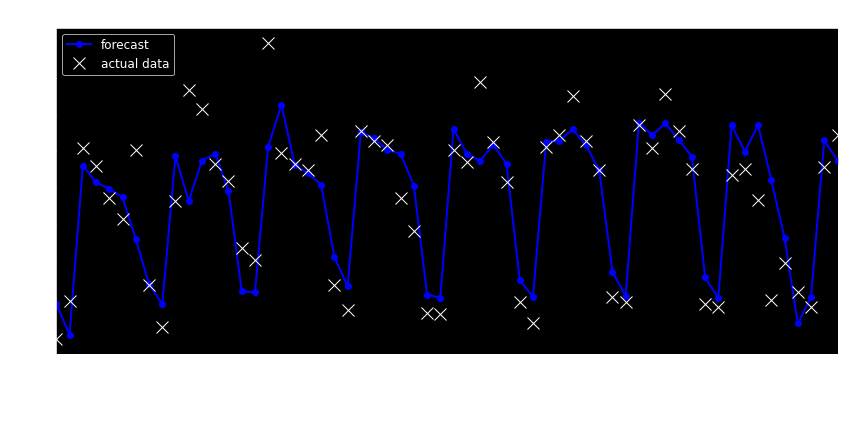

In [27]:
dataframes_fh_1['SARIMA'].fcst.plot(label='forecast', color='blue', marker='o', linewidth=2)
dataframes_fh_1['SARIMA'].y_test.plot(label='actual data', color='white', marker='x', markersize=12, linestyle='None')
plt.title('forecasts vs actuals', size=20)
plt.xlabel('forecasting horizon (fh=1)', size=20)
plt.ylabel('counts', size = 20)
plt.gcf().set_size_inches(14, 6)
plt.legend(loc=2, prop={'size': 12})
plt.show()